In [16]:
import os
import numpy as np
import pandas as pd
from Demos.SystemParametersInfo import orig_italic
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import math
from math import exp
import torchvision
from tqdm import tqdm

In [51]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Data prep

In [18]:
def get_img_paths(path):
    img = []
    for dirname, _, filenames in os.walk(path):
        for filename in filenames:
            img.append(os.path.join(dirname, filename))
    return img

train_img = get_img_paths("data/cifar10/train")
test_img = get_img_paths("data/cifar10/test")


In [20]:
valid_count = int(len(test_img) / 2)
valid_img = random.sample(train_img, valid_count)
valid_img_set = set(valid_img)
train_img = [
    filename for filename in train_img
    if filename not in valid_img_set
]

In [21]:
total_samples = len(train_img) + len(valid_img) + len(test_img)
print(f"Number of train samples: {len(train_img)} / {total_samples} ({(len(train_img) / total_samples * 100):.2f}%)")
print(f"Number of validation samples: {len(valid_img)} / {total_samples} ({(len(valid_img) / total_samples * 100):.2f}%)")
print(f"Number of test samples: {len(test_img)} / {total_samples} ({(len(test_img) / total_samples* 100):.2f}%)")

Number of train samples: 45000 / 60000 (75.00%)
Number of validation samples: 5000 / 60000 (8.33%)
Number of test samples: 10000 / 60000 (16.67%)


In [28]:
import csv

train_labels = pd.read_csv('data/cifar10/train_labels.csv').to_dict(orient='records')

test_labels = pd.read_csv('data/cifar10/test_labels.csv').to_dict(orient='records')

In [22]:
def image_transforms():
    return (transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ToTensor()
    ]))

In [32]:


class ImageDataset(Dataset):

    def __init__(self, images, labels, train=True):
        """
        Args:
            images (list): List of image paths or records.
            labels (list): List of corresponding labels.
            train (bool): True if applying training transforms, False otherwise.
        """
        super(ImageDataset, self).__init__()

        self.images = images
        self.labels = labels
        self.train = train

        self.number_images = len(self.images)
        self.image_transforms = image_transforms()

    def __getitem__(self, index):
        actual_index = index % self.number_images

        image = Image.open(self.images[actual_index]).convert('RGB')
        label = self.labels[actual_index]

        if self.train and self.image_transforms is not None:
            image = self.image_transforms(image)
        return image, label

    def __len__(self):
        return self.number_images

train_dataset = ImageDataset(train_img, train_labels, train=True)
valid_dataset = ImageDataset(valid_img, train_labels, train=False)
test_dataset = ImageDataset(test_img, test_labels, train=False)

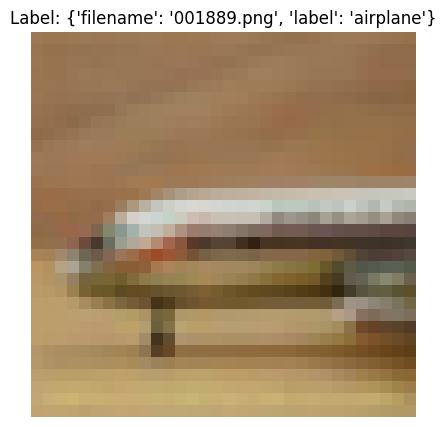

In [49]:
image_tensor, label = train_dataset[random.randint(0, len(train_dataset))]

if isinstance(image_tensor, torch.Tensor):
    image_to_show = image_tensor.permute(1, 2, 0).numpy()

    import numpy as np
    image_to_show = np.clip(image_to_show, 0, 1)
else:
    image_to_show = image_tensor

plt.figure(figsize=(5, 5))
plt.imshow(image_to_show)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# Models

In [61]:
# Basic LeNet test
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5), # 28x28x6
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2), #14x14x6
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5), # 10x10x6\
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2), #5x5x6
            nn.Flatten()
        )
        self.dense = nn.Sequential(
        nn.Linear(16 * 5 * 5, 120),
        nn.Sigmoid(),
        nn.Linear(120, 84),
        nn.Sigmoid(),
        nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.dense(x)
        return x


In [62]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device {DEVICE}')
NUM_WORKERS = os.cpu_count()
print(f'Total available CPUs: {NUM_WORKERS}')

Using device cpu
Total available CPUs: 16


In [63]:
model = LeNet().to(DEVICE)

In [64]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=1e-4, weight_decay=0.0001),
])
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=5e-5,
)